# 14.4-14.5 決定木と専門家の混合 (Decision Trees & Mixture of Experts)

本ノートブックでは、入力空間を局所領域に分割して単純なモデルを割り当てる決定木と、確率的混合モデルの回帰・分類への拡張である **専門家の混合 (Mixture of Experts: MoE)** を学びます。
CART による空間再帰分割と不純度尺度（**PRML Figure 14.5, 14.6**）、多峰性を持つデータセットに対する単一回帰モデルの破綻と **線形回帰混合モデル（Mixture of Linear Regressors, PRML Figure 14.8）** の EM 学習、および多峰的な予測条件付き密度 $p(t|x)$（**PRML Figure 14.9**）を完全実装・再現します。

## 14.4 決定木 (Decision Trees)

決定木は、入力空間を互いに素な領域に分割し、それぞれの領域に対して単純なモデル（通常は定数値）を割り当てることで、全体として複雑な非線形関数を表現する強力な手法です。
**CART (Classification And Regression Trees)** と呼ばれる代表的なアルゴリズムでは、入力空間を座標軸に平行な超平面で再帰的に二分割（Recursive Partitioning）していきます。この単純な分割を繰り返すことで、最終的には元の入力空間が直方体状の領域（葉ノード）の集合に分割されます。

## 14.4 決定木と不純度指標 (PRML Figure 14.5, 14.6)

分類木を構築する際、あるノード $\tau$ をどのように分割するかを決定するために**不純度尺度 (Impurity Measures)** を用います。
ノード $\tau$ に属する学習データのうち、クラス $k$ に属する割合を $p_{\tau,k}$ とします。2クラス分類（$p_{\tau} = p_{\tau,1}$）における代表的な不純度尺度 $Q_{\tau}$ は以下の3つです：

- **交差エントロピー (Cross-Entropy)**: 
  $$ H(p_{\tau}) = -p_{\tau} \ln p_{\tau} - (1 - p_{\tau}) \ln (1 - p_{\tau}) $$
  情報理論に基づき、ノード内の不確実性を測定します。
- **ジニ係数 (Gini Impurity)**: 
  $$ I_G(p_{\tau}) = 2 p_{\tau} (1 - p_{\tau}) $$
  ノードからランダムに選んだ2つのサンプルが異なるクラスに属する確率です。
- **誤分類率 (Misclassification Rate)**: 
  $$ I_M(p_{\tau}) = 1 - \max(p_{\tau}, 1 - p_{\tau}) $$
  多数決でクラスを予測した際の誤り率です。

### 不純度低減と関数の凹性

ノード $\mathcal{D}$ を左右の子ノード $\mathcal{D}_L, \mathcal{D}_R$ に分割した際、不純度の低減量（情報利得）は次のように定義されます：
$$ \Delta Q = Q(\mathcal{D}) - \frac{|\mathcal{D}_L|}{|\mathcal{D}|} Q(\mathcal{D}_L) - \frac{|\mathcal{D}_R|}{|\mathcal{D}|} Q(\mathcal{D}_R) $$
重要な点は、**交差エントロピーとジニ係数は $p_{\tau}$ に対して厳密な凹関数（上に凸）**であるということです。
イェンゼンの不等式により、任意の凹関数 $Q$ に対して $Q(\mathbb{E}[p]) \ge \mathbb{E}[Q(p)]$ が成り立ちます。今回、$p_{\mathcal{D}} = \frac{|\mathcal{D}_L|}{|\mathcal{D}|} p_{\mathcal{D}_L} + \frac{|\mathcal{D}_R|}{|\mathcal{D}|} p_{\mathcal{D}_R}$ であるため、任意の分割において必ず $\Delta Q \ge 0$ となり、不純度が減少することが保証されます。
一方、誤分類率は微分不可能な点を持つため、特定の分割において $\Delta Q = 0$ となってしまうことがあり、木を成長させるための指標としては適切ではありません。

### コスト複雑度剪定 (Cost-Complexity Pruning)

十分に成長させた決定木は過学習を起こしやすいため、成長後に不要な枝を切り落とす**剪定 (Pruning)** を行います。
木 $T$ の全体的なコスト関数を、訓練データ上の損失 $R(T)$ と葉の数 $|T|$ （木の複雑さ）のペナルティの和として定義します：
$$ C_{\alpha}(T) = R(T) + \alpha |T| $$
パラメータ $\alpha \ge 0$ が剪定の強さを制御します。$\alpha$ を 0 から徐々に増加させると、このコスト関数を最小化する最適な部分木のサイズ（葉の数）は単調非増加となります。最適な $\alpha$ は交差検証によって決定されます。

### 回帰木 (Regression Trees)

目標変数が連続値の場合（回帰木）、不純度の代わりにノード内の予測値（平均）と実際の値との**二乗和誤差 (Sum of Squared Residuals)** を分割基準とします。

Plot saved to: result/fig14_tree_impurity_measures.png


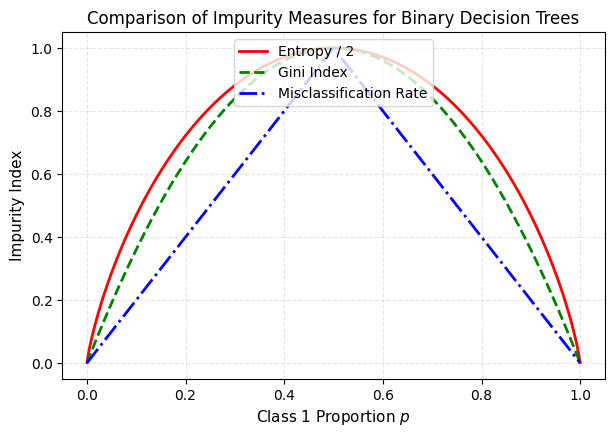

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

p = np.linspace(1e-4, 1.0 - 1e-4, 300)

gini = 4.0 * p * (1.0 - p) # 0.5で1に正規化
entropy = (-p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p))
misclass = 1.0 - np.maximum(p, 1.0 - p)
misclass_scaled = 2.0 * misclass # 0.5で1に正規化

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(p, entropy, 'r-', lw=2.0, label='Entropy / 2')
ax.plot(p, gini, 'g--', lw=2.0, label='Gini Index')
ax.plot(p, misclass_scaled, 'b-.', lw=2.0, label='Misclassification Rate')

ax.set_title('Comparison of Impurity Measures for Binary Decision Trees', fontsize=12)
ax.set_xlabel('Class 1 Proportion $p$', fontsize=11); ax.set_ylabel('Impurity Index', fontsize=11)
ax.legend(loc='upper center', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig14_tree_impurity_measures.png')
plt.show()

## 14.5.1 専門家の混合 (Mixture of Experts) と線形回帰混合モデル (PRML Figure 14.8, 14.9)

入力 $\mathbf{x}$ に対して目標変数 $\mathbf{t}$ を予測する際、入力空間の異なる領域でデータの性質が大きく異なる場合があります。これをモデル化するのが**専門家の混合 (Mixture of Experts)** です。
条件付き混合モデルとして、予測分布を次のように定式化します：
$$ p(\mathbf{t}|\mathbf{x}) = \sum_{k=1}^K \pi_k(\mathbf{x}) p_k(\mathbf{t}|\mathbf{x}) $$

ここには2つの重要な構成要素があります：
1. **専門家ネットワーク (Expert Networks)** $p_k(\mathbf{t}|\mathbf{x})$: 各領域に特化した個別の予測モデル。回帰問題では線形ガウスモデル $p_k(t|\mathbf{x}) = \mathcal{N}(t|\mathbf{w}_k^T\mathbf{x}, \sigma_k^2)$ がよく用いられます。
2. **ゲートネットワーク (Gating Network)** $\pi_k(\mathbf{x})$: 入力 $\mathbf{x}$ が与えられたときに、どの専門家を信頼すべきかの確率（混合係数）を出力します。通常はソフトマックス関数が用いられます：
   $$ \pi_k(\mathbf{x}) = \frac{\exp(\mathbf{v}_k^T\mathbf{x})}{\sum_{j=1}^K \exp(\mathbf{v}_j^T\mathbf{x})} $$

### EM アルゴリズムによる学習

このモデルは、潜在変数 $\mathbf{z}$（どのデータ点がどの専門家に由来するかを示す 1-of-K 符号化ベクトル）を導入することで、EM アルゴリズムにより効率的に学習できます。

- **E ステップ (E-step)**:
  現在のパラメータを用いて、各データ点 $\mathbf{x}_n$ が各専門家 $k$ によって生成された事後確率（負担率/Responsibility） $\gamma_{nk}$ を計算します。
  $$ \gamma_{nk} = \frac{\pi_k(\mathbf{x}_n) p_k(\mathbf{t}_n|\mathbf{x}_n)}{\sum_{j=1}^K \pi_j(\mathbf{x}_n) p_j(\mathbf{t}_n|\mathbf{x}_n)} $$

- **M ステップ (M-step)**:
  負担率 $\gamma_{nk}$ を固定し、完全データの期待対数尤度を最大化するパラメータを求めます。
  専門家ネットワークの重み $\mathbf{w}_k$ は重み付き最小二乗法 (Weighted Least Squares; WLS) により解析的に求まり、ゲートネットワークのパラメータ $\mathbf{v}_k$ は反復再重み付け最小二乗法 (IRLS) などの勾配ベースの最適化で更新します。

### 条件付き期待値 $\mathbb{E}[t|\mathbf{x}]$ の破綻と多峰性

PRML Figure 14.8 のような、同一の入力 $\mathbf{x}$ に対して複数の異なる出力の可能性（多峰性）を持つ逆問題において、単一の回帰モデルは致命的に破綻します。
標準的な回帰モデルは条件付き期待値 $\mathbb{E}[t|\mathbf{x}]$ を学習しようとしますが、多峰性データでは真のモード（峰）の間の「確率の谷（誰もいない場所）」を平均値として出力してしまうからです。
MoE では $p(\mathbf{t}|\mathbf{x})$ 全体をモデル化するため、この問題を回避できます。

### 階層的専門家の混合 (HME)

決定木のソフトなバージョンとして、MoE を木構造に拡張した**階層的専門家の混合 (Hierarchical Mixture of Experts; HME)** も提案されています。これはゲートネットワークが木構造に配置され、葉ノードに専門家が配置されるモデルであり、より複雑な入力空間の分割を可能にします。

Plot saved to: result/fig14_8_9_mixture_linear_regression.png


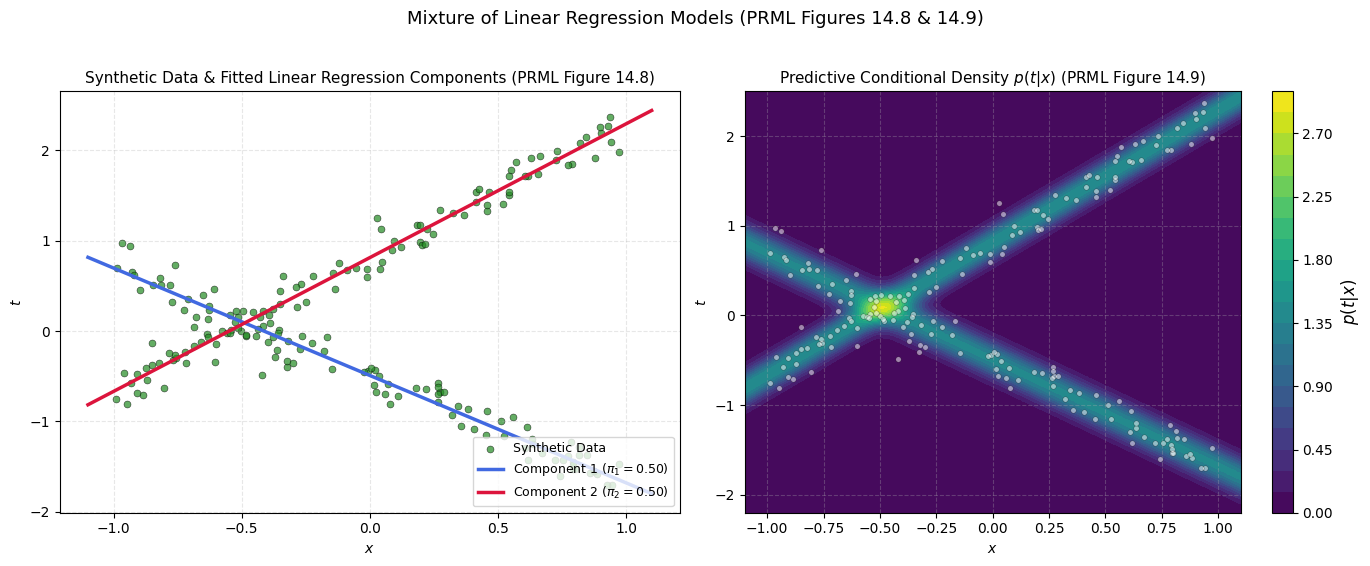

In [2]:
from common.ensemble_utils import MixtureOfLinearRegressions

# 多峰性合成データの生成 (PRML Figure 14.8 準拠: 2つの交差する線形ブランチ)
np.random.seed(42)
N_sub = 100
x_data = np.random.uniform(-1.0, 1.0, N_sub * 2)

# ブランチ 1: t = 1.5 * x + 0.8 + noise
# ブランチ 2: t = -1.2 * x - 0.5 + noise
t_data = np.zeros_like(x_data)
t_data[:N_sub] = 1.5 * x_data[:N_sub] + 0.8 + np.random.normal(0, 0.15, N_sub)
t_data[N_sub:] = -1.2 * x_data[N_sub:] - 0.5 + np.random.normal(0, 0.15, N_sub)

X_in = x_data[:, np.newaxis]

# 2成分線形回帰混合モデルの EM 適合
moe = MixtureOfLinearRegressions(n_components=2, max_iter=60, random_state=42)
moe.fit(X_in, t_data)

# PRML Figure 14.8 & 14.9 のプロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) データ点と学習された各成分の回帰直線 (PRML Figure 14.8)
axes[0].scatter(x_data, t_data, color='forestgreen', s=25, alpha=0.7, edgecolors='k', lw=0.4, label='Synthetic Data')
x_plot = np.linspace(-1.1, 1.1, 100)
Phi_plot = np.column_stack([np.ones_like(x_plot), x_plot])

colors_comp = ['royalblue', 'crimson']
for k in range(moe.n_components):
    y_line = Phi_plot @ moe.weights_[k]
    axes[0].plot(x_plot, y_line, color=colors_comp[k], lw=2.5, label=f'Component {k+1} ($\pi_{k+1}={moe.pi_[k]:.2f}$)')

axes[0].set_title('Synthetic Data & Fitted Linear Regression Components (PRML Figure 14.8)', fontsize=11)
axes[0].set_xlabel('$x$', fontsize=10); axes[0].set_ylabel('$t$', fontsize=10)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# (b) 予測条件付き確率密度 p(t|x) の等高線/ヒートマップ (PRML Figure 14.9)
x_grid = np.linspace(-1.1, 1.1, 120)
t_grid = np.linspace(-2.2, 2.5, 120)
density_map = moe.predict_density(x_grid, t_grid)

im = axes[1].contourf(x_grid, t_grid, density_map, levels=20, cmap='viridis')
plt.colorbar(im, ax=axes[1], label='$p(t|x)$')
axes[1].scatter(x_data, t_data, color='white', s=15, alpha=0.5, edgecolors='k', lw=0.3)

axes[1].set_title('Predictive Conditional Density $p(t|x)$ (PRML Figure 14.9)', fontsize=11)
axes[1].set_xlabel('$x$', fontsize=10); axes[1].set_ylabel('$t$', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Mixture of Linear Regression Models (PRML Figures 14.8 & 14.9)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig14_8_9_mixture_linear_regression.png')
plt.show()